# Five-fold XGBoost regression with five land-cover channels

This standalone experiment predicts Landsat LST from 20 compact radial features: sealed soil, high green, low green, agriculture, and water fractions in four 25 m distance bands. It uses the established five Statbel-sector outer test folds and leakage-safe inner validation sectors with 200 m embargoes. No CNN models are loaded or trained.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'processing' / 'local-layers').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
PACKAGE_ROOT = PROJECT_ROOT / 'processing' / 'local-layers'
if str(PACKAGE_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT / 'src'))

from greenwave_local_layers.image_regression import (
    DEFAULT_OBSERVATION_ID, ImageRegressionDataset, LAND_COVER_CHANNEL_NAMES,
    RADIAL_BAND_EDGES_METERS, load_regression_catalog, make_sector_folds,
    radial_band_fractions,
)
from greenwave_local_layers.image_regression_training import (
    make_sector_validation_split, pooled_regression_metrics,
)
from greenwave_local_layers.image_regression_xgboost import (
    XGBoostConfig, train_xgboost_fold,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

## Fixed folds and model recipe

Each outer fold holds out complete test sectors. Approximately 15% of the eligible outer-training samples are assigned to complete validation sectors, and fitting centres within 200 m of validation or test sectors are excluded. Validation RMSE selects the best boosting round; test targets are evaluated only afterward.

In [2]:
catalog = load_regression_catalog(DEFAULT_OBSERVATION_ID)
outer_folds = make_sector_folds(catalog.samples, n_splits=5, buffer_m=200, seed=42)
inner_splits = tuple(
    make_sector_validation_split(
        catalog.samples, outer_fold, validation_fraction=0.15, buffer_m=200, seed=42,
    )
    for outer_fold in outer_folds
)
config = XGBoostConfig(
    num_boost_round=2_000, early_stopping_rounds=50, learning_rate=0.05,
    max_depth=4, min_child_weight=1.0, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=1.0, seed=42,
)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
radial_bands = tuple(zip(RADIAL_BAND_EDGES_METERS[:-1], RADIAL_BAND_EDGES_METERS[1:]))
feature_names = tuple(
    f'{channel}_{lower}_{upper}m'
    for channel in LAND_COVER_CHANNEL_NAMES for lower, upper in radial_bands
)
assert len(feature_names) == 20

split_rows = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    inner_sets = [
        set(inner_split.fit_indices), set(inner_split.validation_indices),
        set(inner_split.excluded_buffer_indices),
    ]
    assert set.union(*inner_sets) == set(outer_fold.train_indices)
    assert all(inner_sets[a].isdisjoint(inner_sets[b]) for a, b in ((0, 1), (0, 2), (1, 2)))
    assert all(values.isdisjoint(outer_fold.test_indices) for values in inner_sets)
    split_rows.append({
        'fold': outer_fold.fold, 'fit': len(inner_split.fit_indices),
        'validation': len(inner_split.validation_indices),
        'inner embargo': len(inner_split.excluded_buffer_indices),
        'test': len(outer_fold.test_indices),
        'outer embargo': len(outer_fold.excluded_buffer_indices),
        'fit sectors': len(inner_split.fit_sector_ids),
        'validation sectors': len(inner_split.validation_sector_ids),
        'test sectors': len(outer_fold.test_sector_ids),
    })
display(pd.DataFrame(split_rows).set_index('fold'))
display(pd.Series({
    'observation': catalog.observation_id, 'samples': len(catalog.samples),
    'XGBoost': xgb.__version__, 'device': device, 'features': len(feature_names),
    'channels': ', '.join(LAND_COVER_CHANNEL_NAMES),
    'distance bands': ', '.join(f'{a}–{b} m' for a, b in radial_bands),
    'maximum rounds': config.num_boost_round,
    'early-stopping patience': config.early_stopping_rounds,
    'learning rate': config.learning_rate, 'maximum depth': config.max_depth,
    'subsample': config.subsample, 'column sample': config.colsample_bytree,
}).to_frame('value'))

,fit,validation,inner embargo,test,outer embargo,fit sectors,validation sectors,test sectors
fold,,,,,,,,
0,7172,1441,989,3078,2709,93,15,28
1,7291,1542,1441,3078,2037,95,15,28
2,6839,1389,1026,3078,3057,90,14,30
3,6664,1387,1194,3077,3067,94,15,30
4,6976,1393,914,3078,3028,92,15,30


,value
observation,landsat-2026-06-22
samples,15389
XGBoost,3.2.0
device,cuda
features,20
channels,"soil_sealing, high_green, low_green, agricultu..."
distance bands,"0–25 m, 25–50 m, 50–75 m, 75–100 m"
maximum rounds,2000
early-stopping patience,50
learning rate,0.05


## Extract the 20 compact radial features

Each quantity is the number of active classified pixels divided by all valid 1 m pixels in that distance band. These are area-weighted band fractions—not unweighted averages of one-metre annular fractions.

In [3]:
started = time.perf_counter()
features = np.empty((len(catalog.samples), len(feature_names)), dtype=np.float32)
dataset = ImageRegressionDataset(catalog, representation='spatial')
try:
    for catalog_index in range(len(catalog.samples)):
        features[catalog_index] = radial_band_fractions(
            dataset.land_cover_patch(catalog_index)
        ).reshape(-1)
        if (catalog_index + 1) % 2_000 == 0:
            print(f'extracted {catalog_index + 1:,}/{len(catalog.samples):,} samples', flush=True)
finally:
    dataset.close()
assert features.shape == (len(catalog.samples), 20)
assert np.all(np.isfinite(features))
assert np.all((0 <= features) & (features <= 1))
print(f'Feature extraction completed in {time.perf_counter() - started:.1f} seconds.')
feature_summary = pd.DataFrame(features, columns=feature_names).describe().T
display(feature_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4))

extracted 2,000/15,389 samples


extracted 4,000/15,389 samples


extracted 6,000/15,389 samples


extracted 8,000/15,389 samples


extracted 10,000/15,389 samples


extracted 12,000/15,389 samples


extracted 14,000/15,389 samples


Feature extraction completed in 29.7 seconds.


,mean,std,min,25%,50%,75%,max
soil_sealing_0_25m,0.5879,0.2114,0.0071,0.4322,0.5876,0.7490,1.0000
soil_sealing_25_50m,0.4743,0.1942,0.0042,0.3340,0.4646,0.6050,1.0000
soil_sealing_50_75m,0.4202,0.1913,0.0060,0.2802,0.3982,0.5461,0.9980
soil_sealing_75_100m,0.3946,0.1921,0.0020,0.2488,0.3706,0.5234,0.9897
high_green_0_25m,0.1190,0.1450,0.0000,0.0157,0.0617,0.1685,1.0000
high_green_25_50m,0.1627,0.1517,0.0000,0.0503,0.1127,0.2316,0.9375
high_green_50_75m,0.1807,0.1498,0.0000,0.0688,0.1336,0.2540,0.9992
high_green_75_100m,0.1887,0.1485,0.0000,0.0759,0.1445,0.2649,0.9297
low_green_0_25m,0.3021,0.1587,0.0000,0.1832,0.2971,0.4094,0.9190
low_green_25_50m,0.3331,0.1267,0.0000,0.2473,0.3357,0.4189,0.8780


## Five XGBoost models with inner-fold early stopping

In [4]:
targets_c = catalog.samples['lst_c'].to_numpy(dtype=np.float32)
results = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    print(f"\n=== XGBoost outer fold {outer_fold.fold} ===", flush=True)
    result = train_xgboost_fold(
        features, targets_c, outer_fold, inner_split, feature_names,
        config, device=device, verbose=True,
    )
    assert np.array_equal(result.catalog_indices, outer_fold.test_indices)
    assert np.array_equal(result.fit_indices, inner_split.fit_indices)
    assert np.array_equal(result.validation_indices, inner_split.validation_indices)
    results.append(result)
    print(
        f"fold {outer_fold.fold}: best round {result.best_round}, "
        f"stopped {result.stopped_round}, metrics {result.metrics}", flush=True,
    )


=== XGBoost outer fold 0 ===


[0]	fit-rmse:3.67090	validation-rmse:4.79019


[100]	fit-rmse:1.81684	validation-rmse:2.38348


[200]	fit-rmse:1.71262	validation-rmse:2.38078


[218]	fit-rmse:1.69573	validation-rmse:2.37977


...

[300]	fit-rmse:1.61383	validation-rmse:2.75497


[400]	fit-rmse:1.53886	validation-rmse:2.74092


[500]	fit-rmse:1.47663	validation-rmse:2.73325

[564]	fit-rmse:1.43931	validation-rmse:2.73181


fold 4: best round 515, stopped 565, metrics {'count': 3078, 'mae_c': 2.0013366213396355, 'rmse_c': 2.679338048325697, 'r2': 0.4990492679280706, 'mean_error_c': 0.6201218325569693}


## Per-fold and aggregated out-of-fold performance

In [5]:
oof_indices = np.concatenate([result.catalog_indices for result in results])
oof_targets = np.concatenate([result.targets_c for result in results])
oof_predictions = np.concatenate([result.predictions_c for result in results])
assert len(np.unique(oof_indices)) == len(catalog.samples)
assert np.array_equal(np.sort(oof_indices), np.arange(len(catalog.samples)))
assert np.allclose(oof_targets, targets_c[oof_indices])

fold_rows = []
for result, outer_fold, inner_split in zip(results, outer_folds, inner_splits):
    fold_rows.append({
        'fold': result.outer_fold, 'fit': len(inner_split.fit_indices),
        'validation': len(inner_split.validation_indices),
        'inner embargo': len(inner_split.excluded_buffer_indices),
        'test': len(outer_fold.test_indices), 'best round': result.best_round,
        'stopped round': result.stopped_round,
        'MAE (°C)': result.metrics['mae_c'], 'RMSE (°C)': result.metrics['rmse_c'],
        'R²': result.metrics['r2'],
        'Mean signed error (°C)': result.metrics['mean_error_c'],
    })
fold_table = pd.DataFrame(fold_rows).set_index('fold')
display(fold_table.round(4))
metric_columns = ['MAE (°C)', 'RMSE (°C)', 'R²', 'Mean signed error (°C)']
display(fold_table[metric_columns].agg(['mean', 'std']).round(4))

pooled = pooled_regression_metrics(results)
pooled_table = pd.Series({
    'samples': pooled['count'], 'MAE (°C)': pooled['mae_c'],
    'RMSE (°C)': pooled['rmse_c'], 'R²': pooled['r2'],
    'Mean signed error (°C)': pooled['mean_error_c'],
    'mean best round': np.mean([result.best_round for result in results]),
    'mean stopped round': np.mean([result.stopped_round for result in results]),
})
display(pooled_table.to_frame('XGBoost five-channel radial bands').round(4))

,fit,validation,inner embargo,test,best round,stopped round,MAE (°C),RMSE (°C),R²,Mean signed error (°C)
fold,,,,,,,,,,
0,7172,1441,989,3078,169,219,1.9552,2.4704,-0.2517,0.3133
1,7291,1542,1441,3078,128,178,1.7067,2.0824,0.6368,-0.9071
2,6839,1389,1026,3078,84,134,1.8750,2.3133,0.5639,-0.2468
3,6664,1387,1194,3077,24,74,1.6780,2.0658,0.6521,-0.1470
4,6976,1393,914,3078,515,565,2.0013,2.6793,0.4990,0.6201


,MAE (°C),RMSE (°C),R²,Mean signed error (°C)
mean,1.8432,2.3223,0.4200,-0.0735
std,0.1453,0.2612,0.3805,0.5833


,XGBoost five-channel radial bands
samples,15389.0000
MAE (°C),1.8432
RMSE (°C),2.3340
R²,0.5426
Mean signed error (°C),-0.0735
mean best round,184.0000
mean stopped round,234.0000


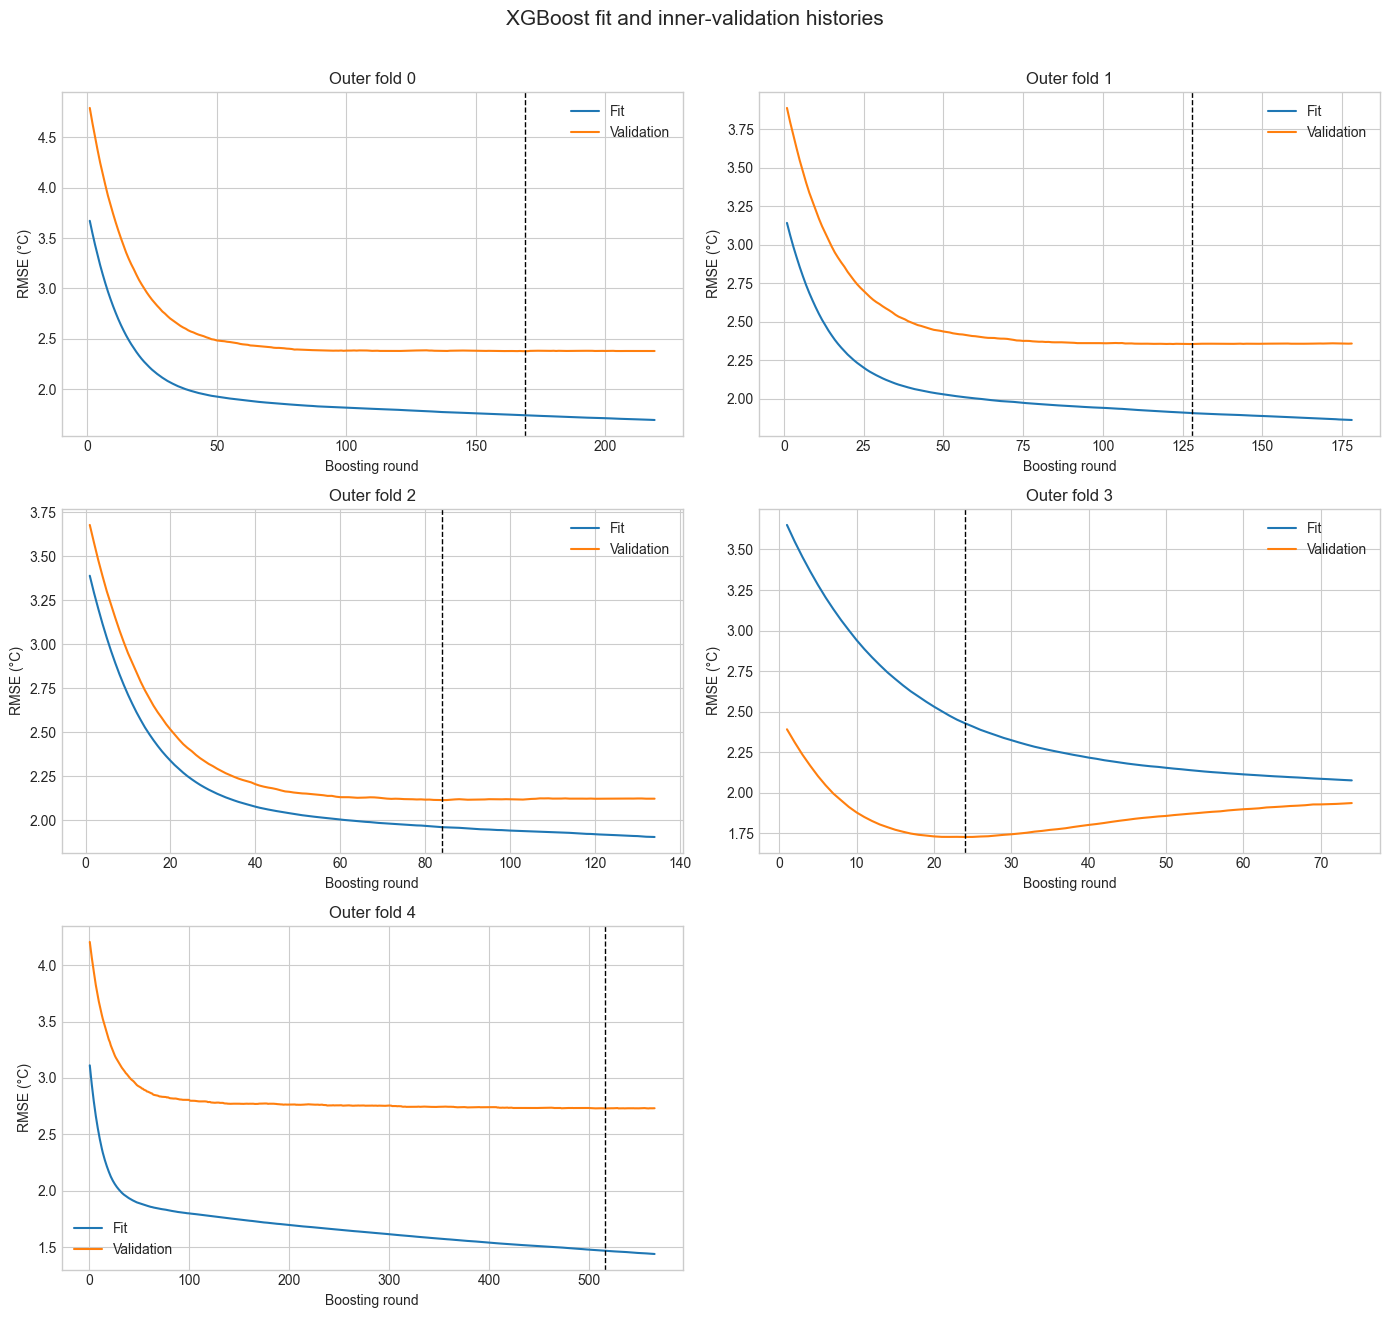

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for result, ax in zip(results, axes.flat):
    rounds = [item['round'] for item in result.history]
    ax.plot(rounds, [item['fit_rmse_c'] for item in result.history], label='Fit')
    ax.plot(rounds, [item['validation_rmse_c'] for item in result.history], label='Validation')
    ax.axvline(result.best_round, color='black', linestyle='--', linewidth=1)
    ax.set(
        title=f'Outer fold {result.outer_fold}', xlabel='Boosting round',
        ylabel='RMSE (°C)',
    )
    ax.legend()
axes.flat[-1].axis('off')
fig.suptitle('XGBoost fit and inner-validation histories', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

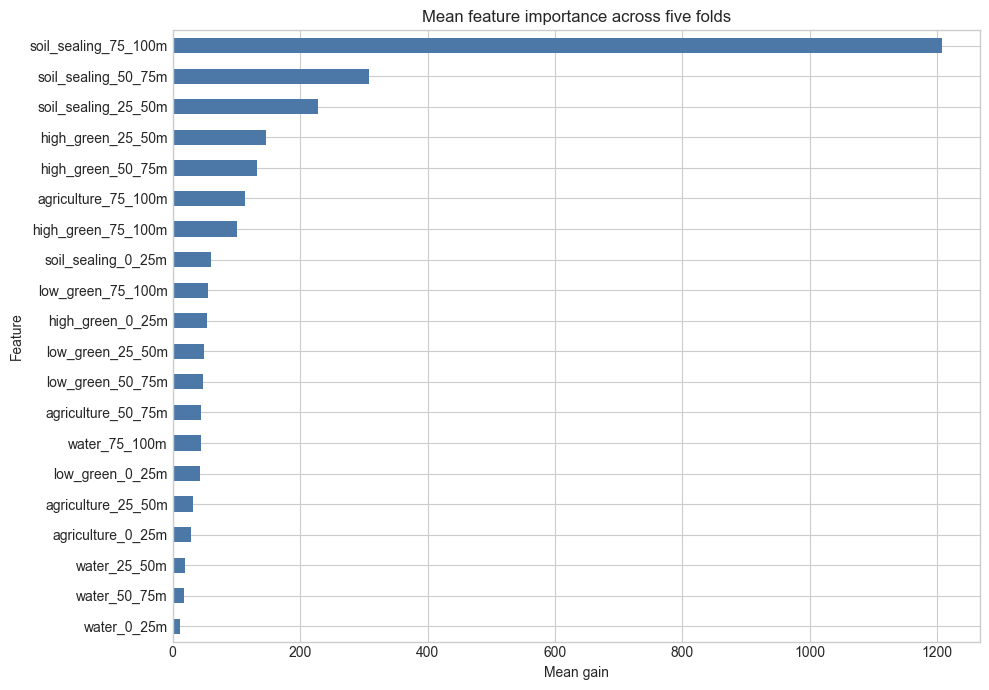

,mean gain
soil_sealing_75_100m,1206.877
soil_sealing_50_75m,307.598
soil_sealing_25_50m,227.452
high_green_25_50m,146.783
high_green_50_75m,132.021
agriculture_75_100m,113.572
high_green_75_100m,100.716
soil_sealing_0_25m,59.731
low_green_75_100m,54.790
high_green_0_25m,53.670


In [7]:
mean_gain = pd.Series({
    name: np.mean([result.feature_importance_gain[name] for result in results])
    for name in feature_names
}).sort_values()
fig, ax = plt.subplots(figsize=(10, 7))
mean_gain.plot.barh(ax=ax, color='#4c78a8')
ax.set(title='Mean feature importance across five folds', xlabel='Mean gain', ylabel='Feature')
plt.tight_layout()
plt.show()
display(mean_gain.sort_values(ascending=False).to_frame('mean gain').round(3))

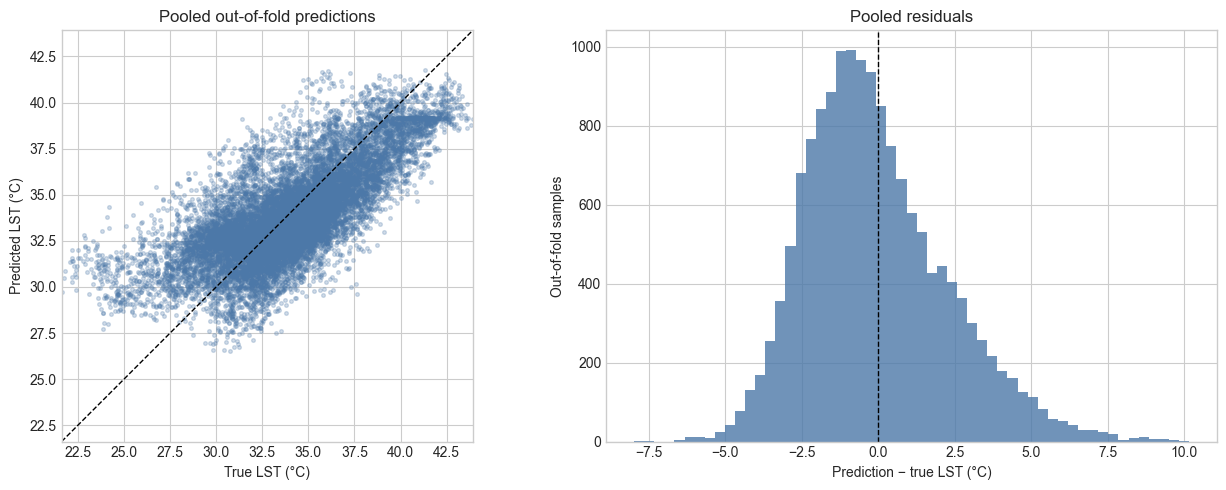

Completed five XGBoost folds on cuda; produced 15,389 unique out-of-fold predictions from 20 five-channel radial-band features.


In [8]:
plot_min = float(min(oof_targets.min(), oof_predictions.min()))
plot_max = float(max(oof_targets.max(), oof_predictions.max()))
residuals = oof_predictions - oof_targets
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(oof_targets, oof_predictions, s=7, alpha=0.25, color='#4c78a8')
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'k--', linewidth=1)
axes[0].set(
    title='Pooled out-of-fold predictions', xlabel='True LST (°C)',
    ylabel='Predicted LST (°C)', xlim=(plot_min, plot_max), ylim=(plot_min, plot_max),
)
axes[0].set_aspect('equal', adjustable='box')
axes[1].hist(residuals, bins=55, color='#4c78a8', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set(
    title='Pooled residuals', xlabel='Prediction − true LST (°C)',
    ylabel='Out-of-fold samples',
)
plt.tight_layout()
plt.show()
print(
    f'Completed five XGBoost folds on {device}; produced {len(oof_indices):,} unique '
    'out-of-fold predictions from 20 five-channel radial-band features.'
)

In [9]:
import folium
import geopandas as gpd
from branca.colormap import LinearColormap
from folium.plugins import HeatMap

prediction_points = catalog.samples.iloc[oof_indices][
    ['sample_id', 'x_lambert', 'y_lambert']
].copy()
prediction_points['predicted_lst_c'] = oof_predictions
prediction_points = gpd.GeoDataFrame(
    prediction_points,
    geometry=gpd.points_from_xy(
        prediction_points.x_lambert, prediction_points.y_lambert, crs='EPSG:31370',
    ),
    crs='EPSG:31370',
).to_crs('EPSG:4326')

heat_min_c, heat_max_c = np.percentile(oof_predictions, [2, 98])
heat_weights = np.clip(
    (oof_predictions - heat_min_c) / (heat_max_c - heat_min_c), 0, 1,
)
heat_data = [
    [point.y, point.x, float(weight)]
    for point, weight in zip(prediction_points.geometry, heat_weights)
]
heat_gradient = {
    0.0: '#440154', 0.25: '#3b528b', 0.5: '#21918c',
    0.75: '#5ec962', 1.0: '#fde725',
}
prediction_map = folium.Map(
    location=[prediction_points.geometry.y.mean(), prediction_points.geometry.x.mean()],
    tiles='OpenStreetMap', control_scale=True, prefer_canvas=True, zoom_start=11,
)
HeatMap(
    heat_data, name='Predicted LST', radius=16, blur=13, min_opacity=0.3,
    max_zoom=15, gradient=heat_gradient,
).add_to(prediction_map)
temperature_legend = LinearColormap(
    colors=list(heat_gradient.values()), vmin=float(heat_min_c), vmax=float(heat_max_c),
    caption='Out-of-fold predicted Landsat LST (°C; heat scale clipped at 2nd–98th percentiles)',
)
temperature_legend.add_to(prediction_map)
prediction_map.fit_bounds([
    [prediction_points.geometry.y.min(), prediction_points.geometry.x.min()],
    [prediction_points.geometry.y.max(), prediction_points.geometry.x.max()],
])
prediction_map